In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (205052, 6)


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

Columns:
['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB

Missing values:
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

Sentiment distribution:
Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


In [4]:
# Remove rows where sentiment is missing
df = df.dropna(subset=["Sentiment"])

# Use Review as the main text
df["Text"] = df["Review"].fillna("")

# Remove rows with empty reviews
df = df[df["Text"].str.strip() != ""]

# Standardise sentiment labels
df["Sentiment"] = df["Sentiment"].astype(str).str.strip().str.title()

print(df[["Text", "Sentiment"]].head())

print("\nSentiment classes:")
print(df["Sentiment"].value_counts())

              Text Sentiment
0           super!  Positive
1          awesome  Positive
2             fair  Positive
3  useless product  Negative
4             fair   Neutral

Sentiment classes:
Sentiment
Positive    147176
Negative     24401
Neutral       8811
Name: count, dtype: int64


In [5]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()

    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenisation
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)


df["Clean_Text"] = df["Text"].apply(clean_text)

df[["Text", "Clean_Text", "Sentiment"]].head()

,Text,Clean_Text,Sentiment
0,super!,super,Positive
1,awesome,awesome,Positive
2,fair,fair,Positive
3,useless product,useless product,Negative
4,fair,fair,Neutral


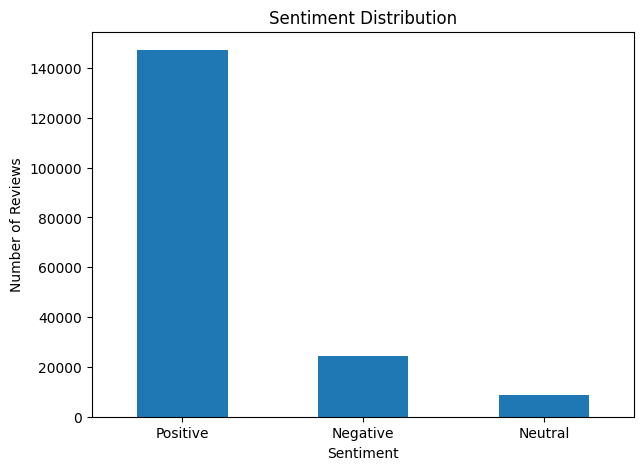

In [6]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [7]:
X_text = df["Clean_Text"]
y = df["Sentiment"]

# 80% training and 20% testing
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 144310
Testing samples: 36078


In [8]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (144310, 686)
Testing TF-IDF shape: (36078, 686)


In [9]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results")
print(classification_report(y_test, nb_pred))

Naive Bayes Results
              precision    recall  f1-score   support

    Negative       0.85      0.71      0.78      4880
     Neutral       0.06      0.00      0.00      1762
    Positive       0.91      0.99      0.95     29436

    accuracy                           0.90     36078
   macro avg       0.61      0.57      0.58     36078
weighted avg       0.86      0.90      0.88     36078



In [10]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, lr_pred))

Logistic Regression Results


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Negative       0.85      0.75      0.80      4880
     Neutral       0.00      0.00      0.00      1762
    Positive       0.92      0.99      0.95     29436

    accuracy                           0.91     36078
   macro avg       0.59      0.58      0.58     36078
weighted avg       0.86      0.91      0.88     36078



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred, average="weighted"),
        precision_score(y_test, lr_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, nb_pred, average="weighted"),
        recall_score(y_test, lr_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, lr_pred, average="weighted")
    ]
})

results

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.903404,0.861363,0.903404,0.878864
1,Logistic Regression,0.908920,0.863108,0.908920,0.884463


In [12]:
results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.9034,0.8614,0.9034,0.8789
1,Logistic Regression,0.9089,0.8631,0.9089,0.8845


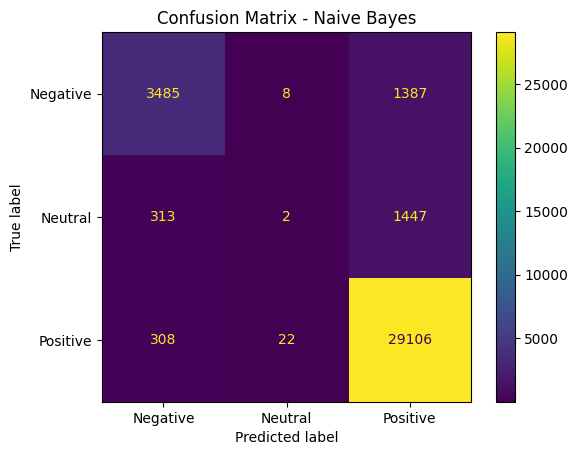

In [13]:
cm_nb = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

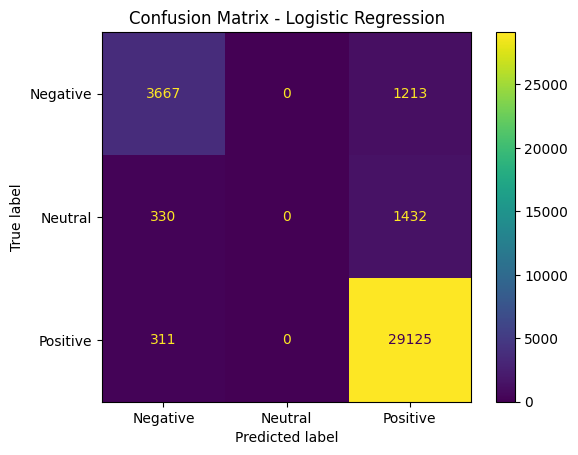

In [14]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

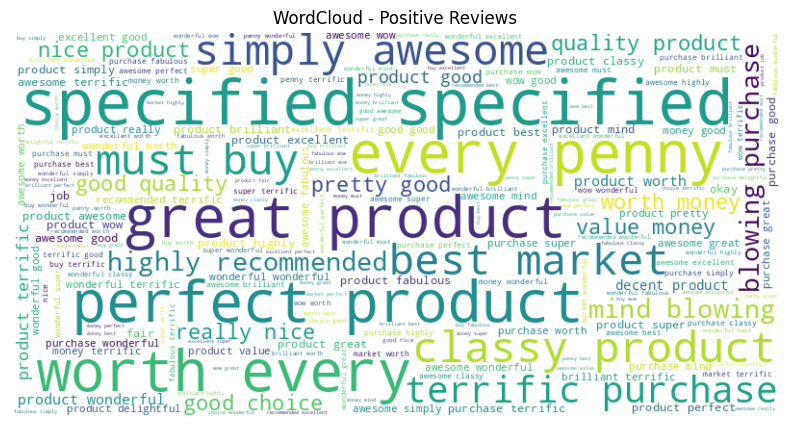

In [15]:
positive_text = " ".join(
    df[df["Sentiment"] == "Positive"]["Clean_Text"]
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Positive Reviews")
plt.show()

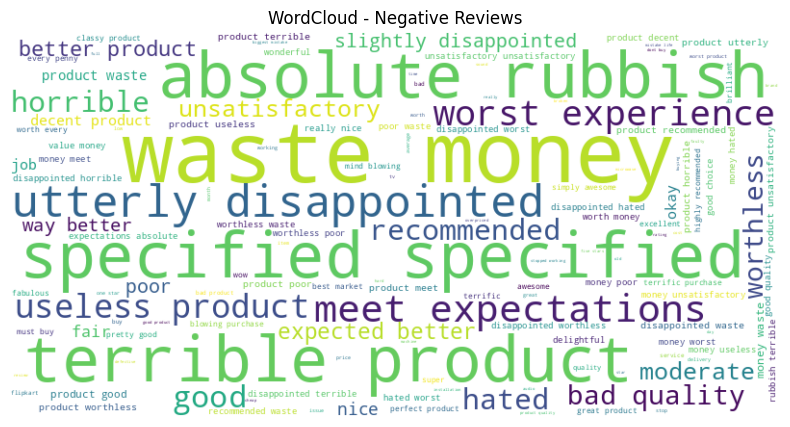

In [16]:
negative_text = " ".join(
    df[df["Sentiment"] == "Negative"]["Clean_Text"]
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Negative Reviews")
plt.show()

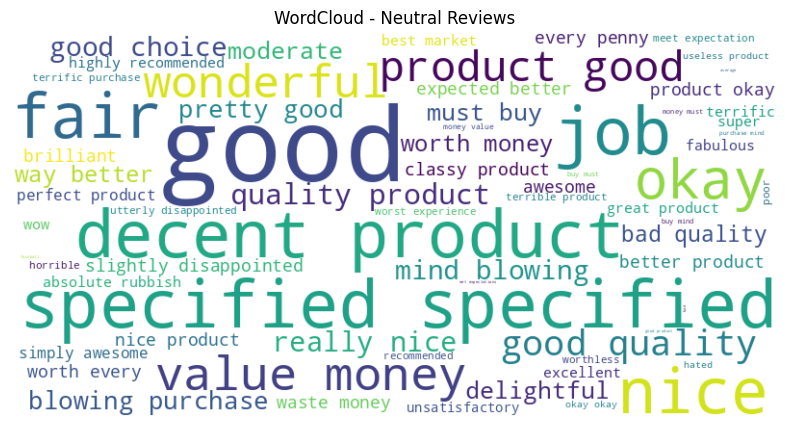

In [17]:
neutral_text = " ".join(
    df[df["Sentiment"] == "Neutral"]["Clean_Text"]
)

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Neutral Reviews")
plt.show()

In [18]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(), "Model"
]

if best_model_name == "Naive Bayes":
    best_predictions = nb_pred
else:
    best_predictions = lr_pred

error_df = pd.DataFrame({
    "Review": X_test_text.values,
    "Actual": y_test.values,
    "Predicted": best_predictions
})

misclassified = error_df[
    error_df["Actual"] != error_df["Predicted"]
]

print("Number of misclassified reviews:", len(misclassified))

misclassified.head(5)

Number of misclassified reviews: 3286


,Review,Actual,Predicted
19,absolute rubbish,Neutral,Negative
31,delightful,Neutral,Positive
53,okay,Negative,Positive
69,good,Negative,Positive
125,nice,Neutral,Positive


In [19]:
for i, row in misclassified.head(5).iterrows():
    print("Review:", row["Review"])
    print("Actual Sentiment:", row["Actual"])
    print("Predicted Sentiment:", row["Predicted"])
    print("-" * 80)

Review: absolute rubbish
Actual Sentiment: Neutral
Predicted Sentiment: Negative
--------------------------------------------------------------------------------
Review: delightful
Actual Sentiment: Neutral
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: okay
Actual Sentiment: Negative
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: good
Actual Sentiment: Negative
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: nice
Actual Sentiment: Neutral
Predicted Sentiment: Positive
--------------------------------------------------------------------------------


In [20]:
best_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1 Score:", round(best_model["F1 Score"], 4))

Best Model: Logistic Regression
Accuracy: 0.9089
Precision: 0.8631
Recall: 0.9089
F1 Score: 0.8845


In [21]:
results.to_csv("sentiment_model_results.csv", index=False)

misclassified.head(5).to_csv(
    "sentiment_error_analysis.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical
features that machine learning models can understand.

Term Frequency measures how often a word appears in a document, while
Inverse Document Frequency reduces the importance of words that occur in
many documents.

TF-IDF gives higher importance to words that are useful for distinguishing
between different reviews and lower importance to very common words.

In this project, TF-IDF features are used as input for the Naive Bayes and
Logistic Regression classifiers.

## Conclusion

Two machine learning models, Naive Bayes and Logistic Regression, were trained
using TF-IDF features for sentiment classification.

The models were evaluated using accuracy, precision, recall and F1-score.
The confusion matrices were also used to understand the classification errors.

The model with the higher F1-score is considered the better-performing model
for this dataset because F1-score provides a balance between precision and
recall.

Sentiment analysis can be used in real-world applications such as analysing
customer reviews, monitoring customer satisfaction, identifying negative
feedback and understanding opinions about products or services.